### Calibration
Calibration begins with ISSW-determined spectral intensities relative to a blank ($I_j(\lambda)$ and $I_0(\lambda$), repectively), as shown in the upper panel of Fig. 1.

<p style='text-align: center;'>
<img src="http://webspace.pugetsound.edu/facultypages/nesh/Notebook/ISSW/I and chi spectra.png" height="500" width="500"/>

__Figure 1__. ISSW-determined spectral intensities of nucleopore filters with India Ink loadings $L$, and a blank (top panel) and absorption optical depths (b).
</p>

Those measurements give rise to an absorption optical depth, $\chi(\lambda)$, of the calibration LAI (in this case, India ink) as a function of filter loading, 

$$
\chi_j = -log\bigl({I_j \over I_0}\bigr) \ \ \ \ (1)
$$

where "$j$" refers to the $j^{th}$ such measurement, corresponding to a known loading $L^{th}$ loaded filter of a standard (see the lower panel of Fig. 1). From these data we obtain a mathematical representation of the dependence of the optical depth on the loading,

$$
\chi(L) = BL + CL^2 + ... \ \ \ \ (2)
$$

which embodies the constraint that $\chi(L=0)=0$. Figure 2 shows an example in which the expansion in Eq. 2 has been truncated at the quadratic term.

<p style='text-align: center;'>
<img src="http://webspace.pugetsound.edu/facultypages/nesh/Notebook/ISSW/chi of L (450).png" height="500" width="500"/>

__Figure 2__. ISSW absorption optical depth $\chi$ as a function of filter loading, and a best-fit quadratic approximation.
</p>

We can invert the shown in Eq. 2, also by a polynomial fit,

$$
L(\chi) = B'L + C'L^2 + ... \ \ \ \ (3)
$$

We're looking for an optical depth that is linear in $L$:

$$
\tau = \beta L \ \ \ \ (4)
$$

Combining these equations, we have

$$
\tau = \beta \times (B'L + C'L^2 + ...) \ \ \ \ (5)
$$

The slope of $\chi$ with respect to $L$ in the limit of small $L$, ${d\chi \over dL}|_{L=0}\equiv \chi'_0$, is equal to $B$ of Eq. 2, a the optical strength of the standard, which we'll call $\overline{\beta}$:

$$
\overline{\beta} \equiv  \chi'_0 \ \ \ \ (3)
$$




**References**

Grenfell, T. C., Doherty, S. J., Clarke, A. D., & Warren, S. G. (2011). Light absorption from particulate impurities in snow and ice determined by spectrophotometric analysis of filters. Applied Optics, 50(14), 2037-2048.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from importlib import reload  # Python 3.4+
import ISSWlib as IS
%matplotlib inline

### India ink standard on millipore filters

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt
UPS_INKStandards//loadings.txt
[ 0.55  0.86  3.02  6.34 11.8  25.4 ]
Reducing number of loadings used from  6  to 5
The shape of chi =  (5, 651)
lambda_450 =  450.0
lambda_600 =  600.0
The shape of chi at those wavelengths =  (5,)
0.06223193147969459
0.05498244495094332
0.4305248611059947


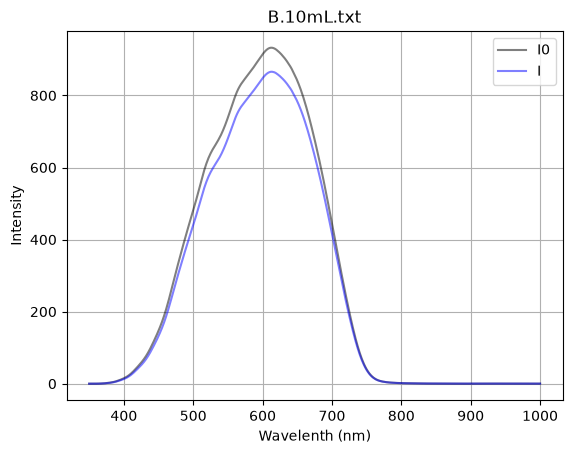

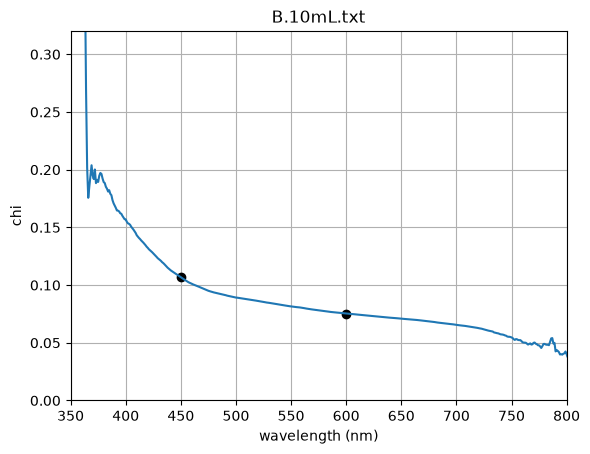

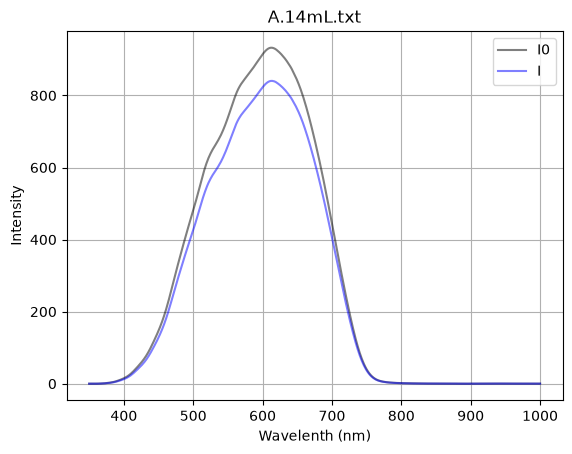

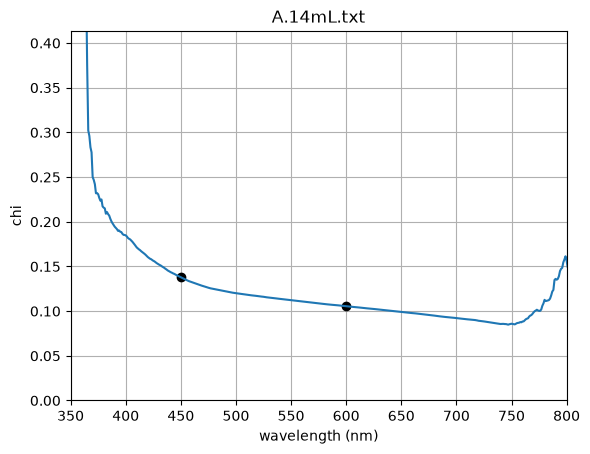

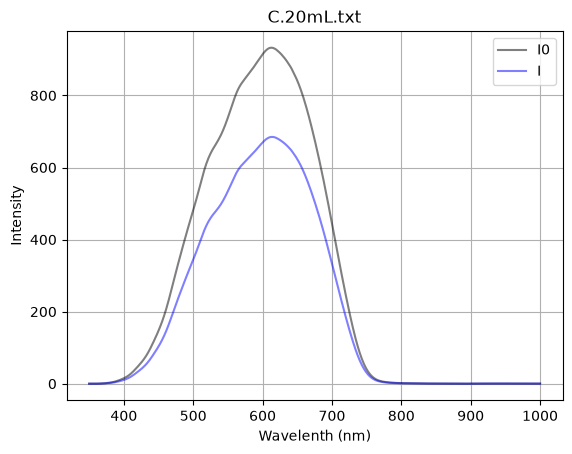

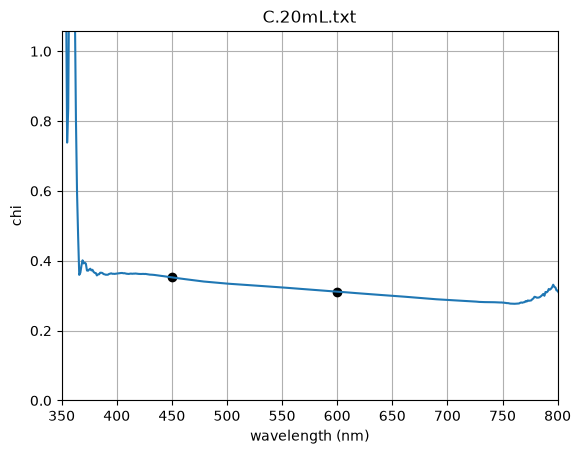

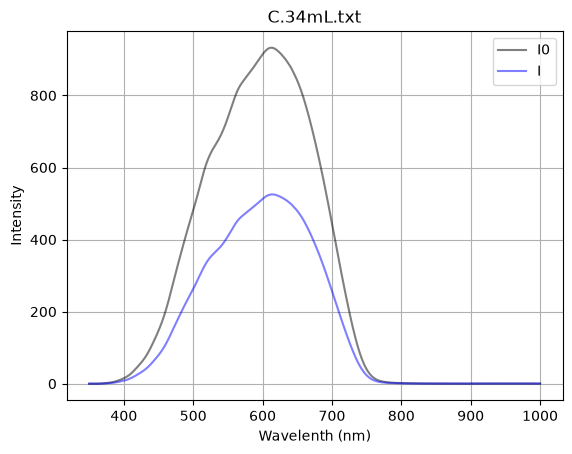

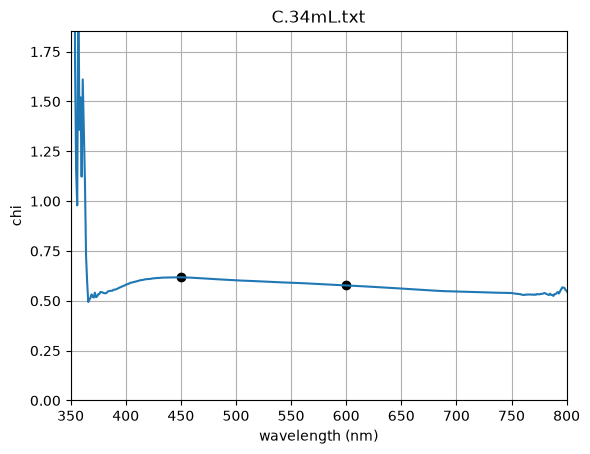

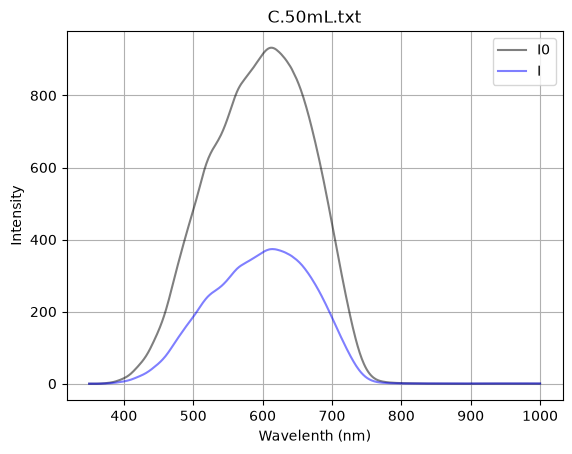

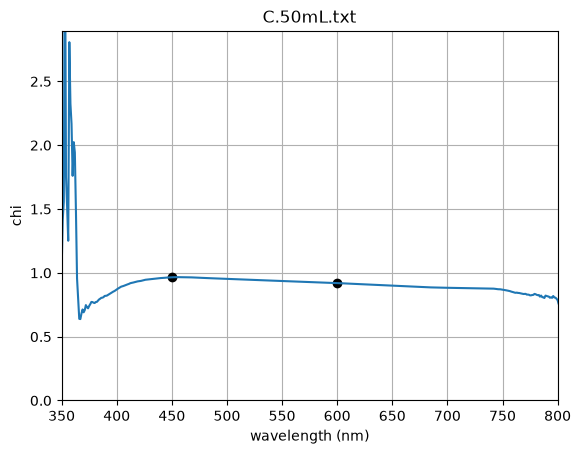

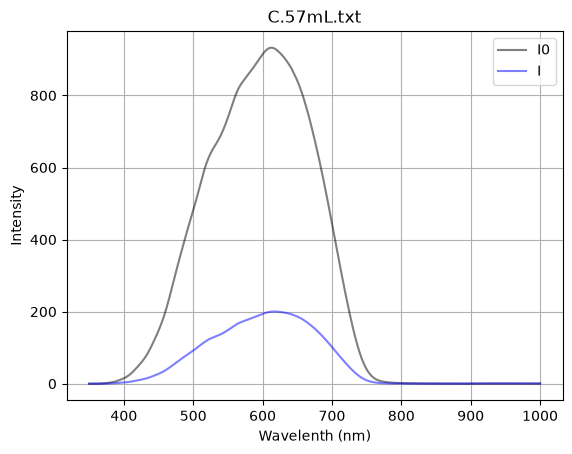

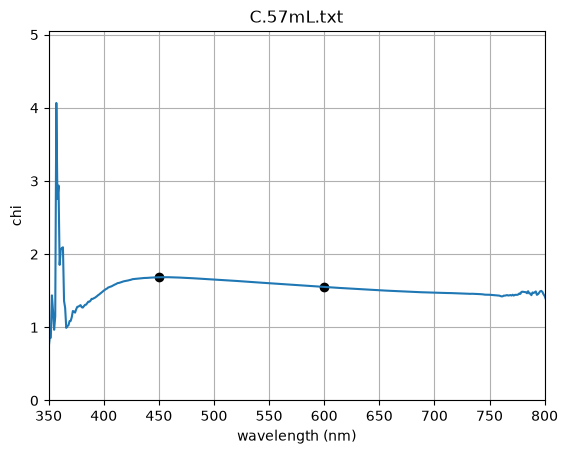

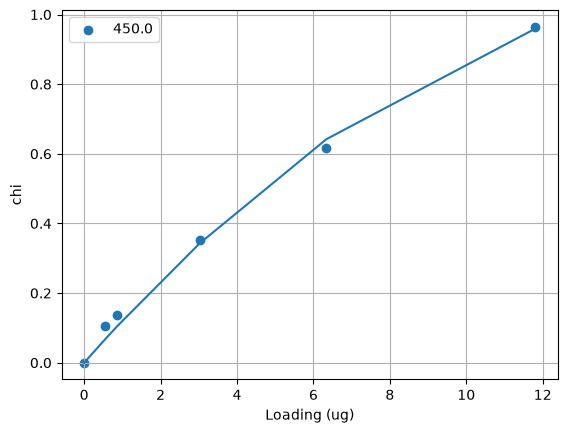

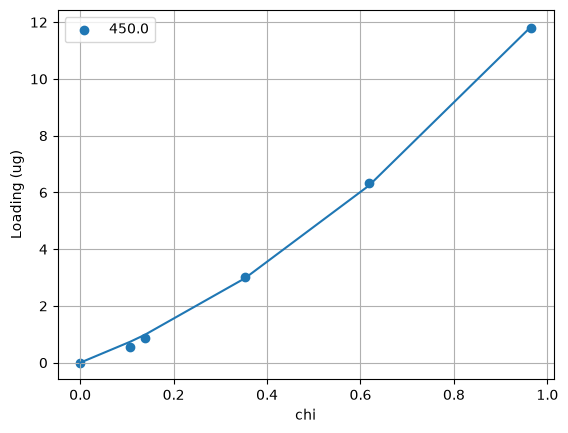

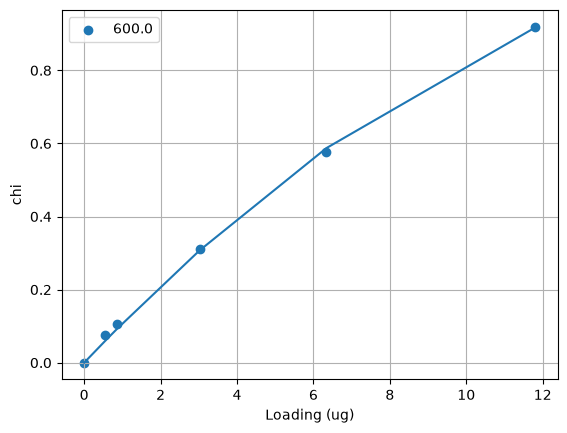

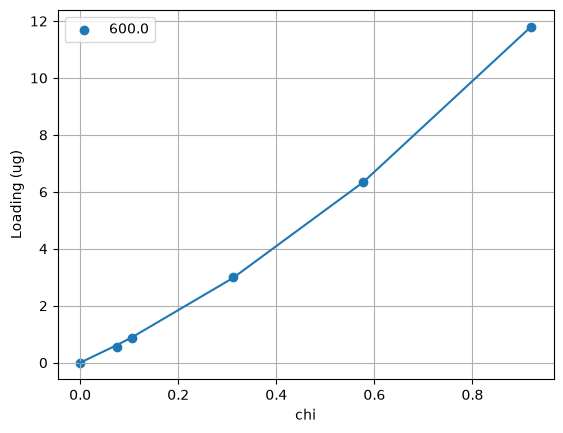

In [3]:
# Load the ISSW spectrum of the standard
spectrum_folder = 'UPS_INKStandards/'; filtertype_std = 'nucleopore'
subset_start = 0 # if 0, we want the start
subset_stop = -2 # if -1, we want all the way to the end
lambda_nm, L_range, chi_range, spectrum_list, number_of_loadings = IS.get_chi_std(spectrum_folder,subset_start,subset_stop)
print('The shape of chi = ', np.shape(chi_range))

# Pull out the values of chi at specific wavelengths
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
chi_range_450 = chi_range[:,I_450]
chi_range_600 = chi_range[:,I_600]
print('The shape of chi at those wavelengths = ', np.shape(chi_range_450))

# Getting calibration parameters at the two wavelengths, and the AAE from those 
p_L_450, betabar_450 = IS.get_calibration_parameters(L_range,chi_range_450,lambda_nm,I_450,order=2,plotting=True)
p_L_600, betabar_600 = IS.get_calibration_parameters(L_range,chi_range_600,lambda_nm,I_600,order=2,plotting=True)
AAE = (-np.log(betabar_450/betabar_600)/np.log(450/600))
print(betabar_450)
print(betabar_600)
print(AAE)

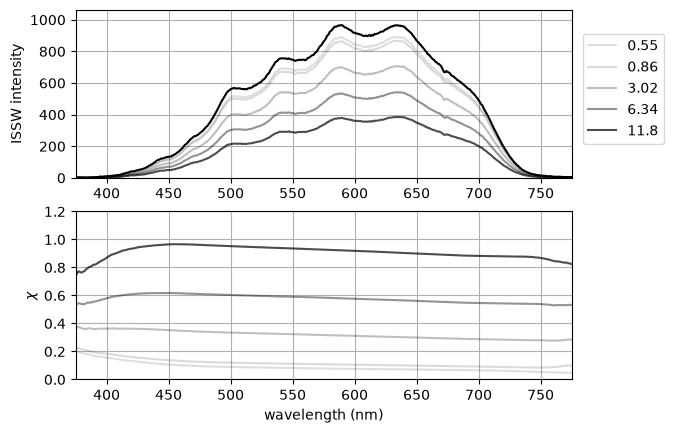

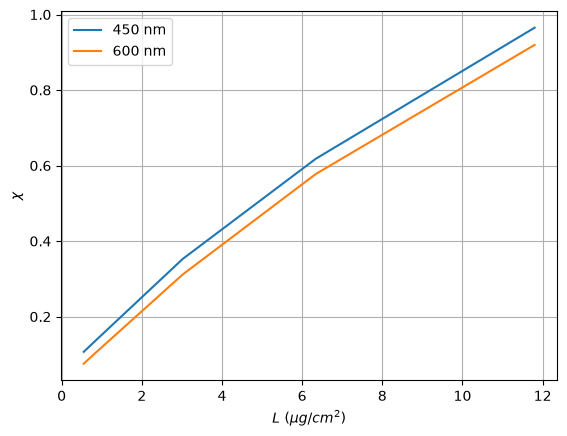

In [15]:
# This is producing some graphs to look at
lambda_start = 375
lambda_stop = 775
plt.subplot(2,1,1)
lambda_nm, I0 = IS.get_spectrum(spectrum_folder+'Blank.txt')
I_base = I0[0]
I0 -= I_base
alpha = 1-((1-(L_range/L_range[-1])*.6)-.1)

plt.plot(lambda_nm,I0,color='k')
# for j in reversed(range(len(L_range))):
for j in range(len(L_range)):
    lambda_nm, I_j = IS.get_spectrum(spectrum_folder+spectrum_list[j])
    I_j -= I_base
    plt.plot(lambda_nm,I_j,color='k',alpha=alpha[j])
plt.xlim([lambda_start,lambda_stop])
plt.ylim([0,np.max(I0)*1.1])
# plt.xlabel('wavelength (nm)')
plt.ylabel('ISSW intensity')
plt.grid('True')

plt.subplot(2,1,2)
for j in range(len(L_range)):
    plt.plot(lambda_nm,chi_range[j,:],color='k',alpha=alpha[j],label=str(L_range[j]))
plt.xlim([lambda_start,lambda_stop])
plt.ylim([0,1.2])
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$\chi$')
plt.grid('True')
plt.legend(bbox_to_anchor=(1.2, 2.1))

plt.figure()
plt.plot(L_range,chi_range_450,label='450 nm')
plt.plot(L_range,chi_range_600,label='600 nm')
plt.xlabel(r'$L \ (μg/cm^2)$')
plt.ylabel(r'$\chi$')
plt.grid('True')
plt.legend()

### Pretending this is a retrieval (as a test)

LAHM loading, std-equivalent @450, 600, AAE =  B.10mL.txt 0.55 0.7366226688409885 0.6231264614734315 1.012161008856737
LAHM loading, std-equivalent @450, 600, AAE =  A.14mL.txt 0.86 0.9781001238293923 0.8901987414684958 0.7578559918843515
LAHM loading, std-equivalent @450, 600, AAE =  C.20mL.txt 3.02 2.9768240667575996 2.975290798670599 0.43231573085005076
LAHM loading, std-equivalent @450, 600, AAE =  C.34mL.txt 6.34 6.240964900202435 6.346201163792117 0.3723996190578408
LAHM loading, std-equivalent @450, 600, AAE =  C.50mL.txt 11.8 11.841684385354812 11.801797919606596 0.44225307083394555


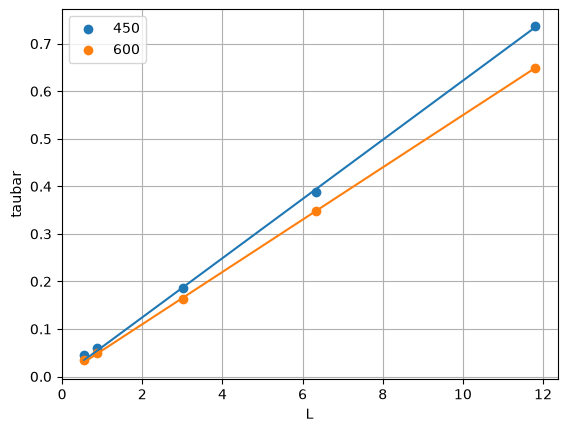

In [4]:
# Now, pretending this is a retrieval ... we already have chi_range_450 and chi_range_600
chi_450_obs = chi_range_450
chi_600_obs = chi_range_600

betabar_450_std = betabar_450
betabar_600_std = betabar_600
AAE_std = AAE

# Reduced optical depths
taubar_450_obs = betabar_450_std*np.polyval(p_L_450,chi_450_obs)
taubar_600_obs = betabar_600_std*np.polyval(p_L_600,chi_600_obs)
taubar_450_theory = betabar_450_std*L_range
taubar_600_theory = betabar_600_std*L_range

plt.figure()
plt.scatter(L_range,taubar_450_obs,label='450')
plt.scatter(L_range,taubar_600_obs,label='600')
plt.grid(True)
plt.legend()
plt.plot(L_range,taubar_450_theory)
plt.plot(L_range,taubar_600_theory)
plt.xlabel('L')
plt.ylabel('taubar')

# Get the AAE implied by these optical depths
AAE_obs = -np.log(taubar_450_obs/taubar_600_obs)/np.log(450/600)

# Assuming the standard's beta values, get equivalent loadings
L_450_equiv = taubar_450_obs/betabar_450_std
L_600_equiv = taubar_600_obs/betabar_600_std

# Report out
for j in range(number_of_loadings):
    print('LAHM loading, std-equivalent @450, 600, AAE = ', spectrum_list[j], L_range[j], L_450_equiv[j], L_600_equiv[j], AAE_obs[j])

In [5]:
# Saving parameters
parameter_filename = 'calibration IV parameters ('+filtertype_std+ ') (July 23, 2026).csv'
calibration_spectrum_folder = spectrum_folder
Save_parameter_flag = True
if Save_parameter_flag:

    print('Saving the parameter file:')
    print(parameter_filename)
    data = {
    "calibration_spectrum_folder": [calibration_spectrum_folder],
    "betabar_450_std": [betabar_450_std],
    "betabar_600_std": [betabar_600_std],
    "filtertype_std": [filtertype_std],
    "p_L_450": [p_L_450],
    "p_L_600": [p_L_600],
    "AAE_std": [AAE_std]
    }
    df = pd.DataFrame(data)
    
    # Display the DataFrame
    display(df)
    print(p_L_450)
    print(p_L_600)

    df.to_csv(parameter_filename, index=False)

Saving the parameter file:
calibration IV parameters (nucleopore) (July 23, 2026).csv


,calibration_spectrum_folder,betabar_450_std,betabar_600_std,filtertype_std,p_L_450,p_L_600,AAE_std
0,UPS_INKStandards/,0.062232,0.054982,nucleopore,"[6.255862295020168, 6.232332702941912, -2.0419...","[5.40369812816501, 7.8648865863139426, -6.6615...",0.430525


[ 6.25586230e+00  6.23233270e+00 -2.04196145e-05]
[ 5.40369813e+00  7.86488659e+00 -6.66150850e-06]
